# Verification — Rosenstein LLE parameter robustness

**Scope:** processed PPG, primary 60 s windows, and the existing `analysis_included`/processed-stationarity mask only. The nominal phase-space configuration (`m=8`, `τ=0.16 s`) remains frozen. No preprocessing, segmentation, SQI, stationarity, labeling, or phase-space selection is rerun.

Three targeted checks are performed: fit-range sensitivity, QC-threshold sensitivity, and local Theiler-window sensitivity. Parameters are not selected from p-values or Awake–Drowsy separation. Nominal cached LLE outputs are reused wherever possible.

In [1]:
# Setup, frozen configuration, and CPU limits
import os
for variable in (
    "OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS",
):
    os.environ[variable] = "1"

import hashlib
import json
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from joblib import Parallel, delayed, parallel_backend
from scipy.stats import rankdata, wilcoxon
from threadpoolctl import threadpool_limits


def find_project_root(start):
    for path in (start, *start.parents):
        if (path / "phase1" / "src").is_dir():
            return path
    raise FileNotFoundError("Cannot locate the project root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "phase1" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from dataloader.loader import load_segmented_session
from chaos.lyapunov import (
    compute_rosenstein_lle,
    estimate_mean_period,
    find_nearest_neighbors,
    reconstruct_phase_space,
)

REPRESENTATION = "processed"
WINDOW_SIZE_S = 60
M = 8
TAU_S = 0.16
FIT_START_S = 0.80
FIT_END_S = 1.30
MAX_FOLLOW_S = 5.0
MIN_INITIAL_PAIRS = 50
MIN_FIT_PAIRS = 30
MIN_R2 = 0.90
FIT_RANGES = {
    "F1: 0.60–1.10 s": (0.60, 1.10),
    "F2: 0.80–1.30 s (nominal)": (0.80, 1.30),
    "F3: 1.00–1.50 s": (1.00, 1.50),
}
THEILER_MULTIPLIERS = {
    "T1: 0.75×": 0.75,
    "T2: 1.00× (nominal)": 1.00,
    "T3: 1.25×": 1.25,
}
QC_THRESHOLDS = {
    "Q1: R² ≥ 0.90 (nominal)": 0.90,
    "Q2: R² ≥ 0.95": 0.95,
}
N_BOOTSTRAP = 20_000
RANDOM_SEED = 20_260_914
N_WORKERS = max(1, (os.cpu_count() or 2) // 2)
STATE_NAMES = {0: "Awake", 1: "Drowsy"}

DATA_DIR = PROJECT_ROOT / "phase1" / "segmentated_data" / "dhdata"
NOMINAL_DIR = PROJECT_ROOT / "phase1" / "results" / "lle" / "processed"
CACHE_DIR = PROJECT_ROOT / "phase1" / "results" / "lle" / "verification"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

CORE_PATH = SRC_DIR / "chaos" / "lyapunov.py"
CONFIG = {
    "representation": REPRESENTATION,
    "window_size_s": WINDOW_SIZE_S,
    "m": M,
    "tau_s": TAU_S,
    "fit_ranges": FIT_RANGES,
    "theiler_multipliers": THEILER_MULTIPLIERS,
    "max_follow_s": MAX_FOLLOW_S,
    "min_initial_pairs": MIN_INITIAL_PAIRS,
    "min_fit_pairs": MIN_FIT_PAIRS,
    "min_r2": MIN_R2,
    "core_sha256": hashlib.sha256(CORE_PATH.read_bytes()).hexdigest(),
}
CONFIG_HASH = hashlib.sha256(
    json.dumps(CONFIG, sort_keys=True).encode()
).hexdigest()
FIT_CACHE = CACHE_DIR / f"fit_range_{CONFIG_HASH[:12]}.csv"
THEILER_CACHE = CACHE_DIR / f"theiler_{CONFIG_HASH[:12]}.csv"

display(pd.DataFrame([
    ["Method", "Rosenstein LLE"],
    ["Primary data", "Processed PPG, 60 s, analysis_included=True"],
    ["Embedding", "m=8; τ=0.16 s"],
    ["Distance / neighbor", "Euclidean / nearest admissible neighbor"],
    ["Nominal Theiler", "Spectral mean period per window"],
    ["Nominal fit", "0.80–1.30 s"],
    ["Maximum follow", "5.0 s"],
    ["Pair thresholds", "initial ≥50; fitted region ≥30"],
    ["Nominal QC", "R² ≥ 0.90"],
    ["Workers", f"{N_WORKERS} of {os.cpu_count()} logical CPUs; 1 numerical thread/worker"],
], columns=["Item", "Frozen setting"]))

,Item,Frozen setting
0,Method,Rosenstein LLE
1,Primary data,"Processed PPG, 60 s, analysis_included=True"
2,Embedding,m=8; τ=0.16 s
3,Distance / neighbor,Euclidean / nearest admissible neighbor
4,Nominal Theiler,Spectral mean period per window
5,Nominal fit,0.80–1.30 s
6,Maximum follow,5.0 s
7,Pair thresholds,initial ≥50; fitted region ≥30
8,Nominal QC,R² ≥ 0.90
9,Workers,8 of 16 logical CPUs; 1 numerical thread/worker


In [2]:
# Load the existing primary cohort and nominal outputs; do not rerun preprocessing
def session_number(path):
    return int(path.stem.rsplit("_", 1)[-1])


session_paths = sorted(DATA_DIR.glob("sample_*.npz"), key=session_number)
tasks = []
for path in session_paths:
    session_id = session_number(path)
    batches, metadata = load_segmented_session(
        path.stem,
        data_dir=DATA_DIR,
        window_sizes=WINDOW_SIZE_S,
        representation=REPRESENTATION,
        stationarity_only=True,
    )
    batch = batches[WINDOW_SIZE_S]
    for index, signal in enumerate(batch["signal"]):
        signal = np.asarray(signal, dtype=float)
        fs = float(batch["fs"])
        base_period_s = float(estimate_mean_period(signal, fs))
        tasks.append({
            "session": session_id,
            "window_id": int(batch["window_id"][index]),
            "state": STATE_NAMES[int(batch["label"][index])],
            "fs": fs,
            "n_samples": int(signal.size),
            "tau_samples": max(int(np.round(TAU_S * fs)), 1),
            "theiler_base_s": base_period_s,
            "signal": signal,
        })

task_index = pd.DataFrame([
    {key: task[key] for key in (
        "session", "window_id", "state", "fs", "n_samples",
        "tau_samples", "theiler_base_s",
    )}
    for task in tasks
])
assert len(tasks) == 901
assert task_index["session"].nunique() == 20
assert not task_index.duplicated(["session", "window_id"]).any()

nominal_files = sorted(NOMINAL_DIR.glob("session_*_processed_rosenstein_lle.csv"))
if len(nominal_files) != 20:
    raise FileNotFoundError("Expected 20 nominal per-session LLE CSV files.")
nominal = pd.concat(
    [pd.read_csv(path) for path in nominal_files], ignore_index=True
)
nominal = nominal.loc[nominal["window_size_s"].eq(WINDOW_SIZE_S)].copy()
nominal["session"] = nominal["session"].astype(int)
nominal["window_id"] = nominal["window_id"].astype(int)
nominal["valid"] = nominal["valid"].astype(bool)
nominal["analysis_included"] = nominal["analysis_included"].astype(bool)

assert len(nominal) == len(tasks) == 901
assert nominal["analysis_included"].all()
assert nominal["representation"].eq(REPRESENTATION).all()
assert nominal["m"].eq(M).all() and np.allclose(nominal["tau_s"], TAU_S)
assert not nominal.duplicated(["session", "window_id"]).any()

identity = ["session", "window_id"]
alignment = task_index.merge(
    nominal[identity + ["state", "tau_samples", "theiler_samples"]],
    on=identity,
    suffixes=("_loaded", "_cached"),
    validate="one_to_one",
)
assert len(alignment) == 901
assert alignment["state_loaded"].eq(alignment["state_cached"]).all()
assert alignment["tau_samples_loaded"].eq(alignment["tau_samples_cached"]).all()
expected_theiler = np.maximum(
    np.rint(alignment["theiler_base_s"] * alignment["fs"]).astype(int), 1
)
assert np.array_equal(expected_theiler, alignment["theiler_samples"].to_numpy(int))

coverage = task_index.groupby("state").size().rename("windows").to_frame().T
coverage.insert(0, "sessions", task_index["session"].nunique())
coverage["total"] = len(task_index)
coverage["nominal_valid_R2_ge_090"] = int(nominal["valid"].sum())
display(coverage)

state,sessions,Awake,Drowsy,total,nominal_valid_R2_ge_090
windows,20,596,305,901,872


In [3]:
# Estimator wrapper, cache schema, validation, and paired inference
RESULT_COLUMNS = [
    "config_hash", "experiment", "setting", "session", "window_id",
    "state", "fs", "n_samples", "m", "tau_s", "tau_samples",
    "fit_start_s", "fit_end_s", "theiler_multiplier",
    "theiler_base_s", "theiler_s", "theiler_samples", "lle",
    "fit_r2", "n_pairs_initial", "n_pairs_fit_min", "valid", "qc_reason",
]


def evaluate_lle(task, experiment, setting, fit_start_s, fit_end_s, multiplier):
    with threadpool_limits(limits=1):
        result = compute_rosenstein_lle(
            task["signal"],
            sampling_rate=task["fs"],
            m=M,
            tau_samples=task["tau_samples"],
            fit_start_s=fit_start_s,
            fit_end_s=fit_end_s,
            max_follow_s=MAX_FOLLOW_S,
            theiler_s=task["theiler_base_s"] * multiplier,
            min_initial_pairs=MIN_INITIAL_PAIRS,
            min_fit_pairs=MIN_FIT_PAIRS,
            min_r2=MIN_R2,
        )
    return {
        "config_hash": CONFIG_HASH,
        "experiment": experiment,
        "setting": setting,
        "session": task["session"],
        "window_id": task["window_id"],
        "state": task["state"],
        "fs": task["fs"],
        "n_samples": task["n_samples"],
        "m": M,
        "tau_s": TAU_S,
        "tau_samples": task["tau_samples"],
        "fit_start_s": fit_start_s,
        "fit_end_s": fit_end_s,
        "theiler_multiplier": multiplier,
        "theiler_base_s": task["theiler_base_s"],
        "theiler_s": result.theiler_s,
        "theiler_samples": result.theiler_samples,
        "lle": result.lle,
        "fit_r2": result.fit_r2,
        "n_pairs_initial": result.n_pairs_initial,
        "n_pairs_fit_min": result.n_pairs_fit_min,
        "valid": result.valid,
        "qc_reason": result.qc_reason,
    }


task_metadata = task_index.set_index(["session", "window_id"])


def nominal_rows(experiment, setting):
    multiplier = 1.0
    merged = nominal.merge(
        task_index[["session", "window_id", "theiler_base_s"]],
        on=["session", "window_id"],
        validate="one_to_one",
    )
    frame = pd.DataFrame({
        "config_hash": CONFIG_HASH,
        "experiment": experiment,
        "setting": setting,
        "session": merged["session"],
        "window_id": merged["window_id"],
        "state": merged["state"],
        "fs": merged["sampling_rate_hz"],
        "n_samples": merged["n_samples"],
        "m": merged["m"],
        "tau_s": merged["tau_s"],
        "tau_samples": merged["tau_samples"],
        "fit_start_s": FIT_START_S,
        "fit_end_s": FIT_END_S,
        "theiler_multiplier": multiplier,
        "theiler_base_s": merged["theiler_base_s"],
        "theiler_s": merged["theiler_s"],
        "theiler_samples": merged["theiler_samples"],
        "lle": merged["lle_1_per_s"],
        "fit_r2": merged["fit_r2"],
        "n_pairs_initial": merged["n_pairs_initial"],
        "n_pairs_fit_min": merged["n_pairs_fit_min"],
        "valid": merged["valid"].astype(bool),
        "qc_reason": merged["qc_reason"],
    })
    return frame[RESULT_COLUMNS]


def validate_result_frame(frame, experiment, settings):
    missing = set(RESULT_COLUMNS).difference(frame.columns)
    if missing:
        raise ValueError(f"Missing result columns: {sorted(missing)}")
    frame = frame[RESULT_COLUMNS].copy()
    frame["valid"] = frame["valid"].astype(bool)
    if len(frame) != len(tasks) * len(settings):
        raise ValueError(f"Unexpected {experiment} cache row count: {len(frame)}")
    if set(frame["setting"]) != set(settings):
        raise ValueError(f"Unexpected {experiment} settings.")
    if not frame["config_hash"].eq(CONFIG_HASH).all():
        raise ValueError(f"Stale {experiment} configuration hash.")
    if frame.duplicated(["setting", "session", "window_id"]).any():
        raise ValueError(f"Duplicate {experiment} identities.")
    expected_ids = set(map(tuple, task_index[["session", "window_id"]].to_numpy()))
    for setting, group in frame.groupby("setting"):
        found = set(map(tuple, group[["session", "window_id"]].to_numpy()))
        if found != expected_ids:
            raise ValueError(f"Window mask differs for {experiment}/{setting}.")
    if not frame["m"].eq(M).all() or not np.allclose(frame["tau_s"], TAU_S):
        raise ValueError(f"Frozen embedding changed in {experiment}.")
    return frame


def write_csv_atomic(frame, path):
    temporary = path.with_suffix(path.suffix + ".tmp")
    frame.to_csv(temporary, index=False)
    temporary.replace(path)


def paired_inference(frame, setting_order, seed_offset=0):
    rows = []
    deltas = {}
    for index, setting in enumerate(setting_order):
        group = frame.loc[frame["setting"].eq(setting)].copy()
        valid = group.loc[
            group["valid"].astype(bool)
            & np.isfinite(group["lle"])
            & np.isfinite(group["fit_r2"])
        ]
        session_state = (
            valid.groupby(["session", "state"], observed=True)["lle"]
            .median().unstack("state").reindex(columns=["Awake", "Drowsy"])
        )
        paired = session_state.dropna()
        delta = (paired["Drowsy"] - paired["Awake"]).to_numpy(float)
        delta[np.isclose(delta, 0.0, atol=1e-12, rtol=0.0)] = 0.0
        rng = np.random.default_rng(RANDOM_SEED + seed_offset + index)
        if len(delta):
            boot = np.median(
                rng.choice(delta, size=(N_BOOTSTRAP, len(delta)), replace=True),
                axis=1,
            )
            ci_low, ci_high = np.percentile(boot, [2.5, 97.5])
        else:
            ci_low = ci_high = np.nan
        nonzero = delta[delta != 0]
        if len(nonzero):
            ranks = rankdata(np.abs(nonzero), method="average")
            r_rb = float(np.sum(ranks * np.sign(nonzero)) / np.sum(ranks))
            p_value = float(wilcoxon(
                delta, zero_method="wilcox", correction=False,
                alternative="two-sided", method="auto",
            ).pvalue)
        else:
            r_rb, p_value = 0.0, 1.0
        finite_r2 = group.loc[np.isfinite(group["fit_r2"]), "fit_r2"]
        finite_pairs = group.loc[
            group["n_pairs_fit_min"].gt(0), "n_pairs_fit_min"
        ]
        rows.append({
            "setting": setting,
            "total_windows": len(group),
            "valid_windows": len(valid),
            "valid_fraction": len(valid) / len(group),
            "valid_awake": int(valid["state"].eq("Awake").sum()),
            "valid_drowsy": int(valid["state"].eq("Drowsy").sum()),
            "paired_sessions": len(delta),
            "median_delta": float(np.median(delta)) if len(delta) else np.nan,
            "ci_low": float(ci_low),
            "ci_high": float(ci_high),
            "r_rb": r_rb,
            "n_negative": int((delta < 0).sum()),
            "n_positive": int((delta > 0).sum()),
            "n_zero": int((delta == 0).sum()),
            "p": p_value,
            "median_fit_r2": float(finite_r2.median()),
            "iqr_fit_r2": float(finite_r2.quantile(.75) - finite_r2.quantile(.25)),
            "median_pairs_fit_min": float(finite_pairs.median()),
            "iqr_pairs_fit_min": float(finite_pairs.quantile(.75) - finite_pairs.quantile(.25)),
        })
        deltas[setting] = pd.Series(delta, index=paired.index, name="delta")
    return pd.DataFrame(rows), deltas

In [4]:
# One-session smoke test, then cached full-dataset batch
smoke_session = int(task_index["session"].min())
smoke_tasks = [task for task in tasks if task["session"] == smoke_session]
remaining_tasks = [task for task in tasks if task["session"] != smoke_session]


def nonnominal_configs(experiment):
    if experiment == "fit_range":
        return [
            (name, start, end, 1.0)
            for name, (start, end) in FIT_RANGES.items()
            if not np.isclose(start, FIT_START_S)
        ]
    return [
        (name, FIT_START_S, FIT_END_S, multiplier)
        for name, multiplier in THEILER_MULTIPLIERS.items()
        if not np.isclose(multiplier, 1.0)
    ]


def evaluate_jobs(selected_tasks, experiment):
    jobs = [
        (task, setting, start, end, multiplier)
        for task in selected_tasks
        for setting, start, end, multiplier in nonnominal_configs(experiment)
    ]
    with parallel_backend("loky", inner_max_num_threads=1):
        rows = Parallel(n_jobs=N_WORKERS, batch_size=1, verbose=5)(
            delayed(evaluate_lle)(
                task, experiment, setting, start, end, multiplier
            )
            for task, setting, start, end, multiplier in jobs
        )
    return pd.DataFrame(rows, columns=RESULT_COLUMNS)


cache_specs = {
    "fit_range": (FIT_CACHE, list(FIT_RANGES), "F2: 0.80–1.30 s (nominal)"),
    "theiler": (THEILER_CACHE, list(THEILER_MULTIPLIERS), "T2: 1.00× (nominal)"),
}
smoke_by_experiment = {}
for experiment, (cache_path, settings, nominal_setting) in cache_specs.items():
    if cache_path.exists():
        cached = validate_result_frame(pd.read_csv(cache_path), experiment, settings)
        smoke_by_experiment[experiment] = cached.loc[
            cached["session"].eq(smoke_session)
            & cached["setting"].ne(nominal_setting)
        ].copy()
        print(f"{experiment}: validated existing cache; smoke rows reused.")
    else:
        smoke = evaluate_jobs(smoke_tasks, experiment)
        expected_smoke = len(smoke_tasks) * (len(settings) - 1)
        assert len(smoke) == expected_smoke
        assert not smoke.duplicated(["setting", "session", "window_id"]).any()
        assert set(smoke["setting"]) == set(settings).difference({nominal_setting})
        smoke_by_experiment[experiment] = smoke
        print(
            f"{experiment}: Session {smoke_session} smoke test passed "
            f"({len(smoke)} rows, schema/QC valid)."
        )


def obtain_full_results(experiment):
    cache_path, settings, nominal_setting = cache_specs[experiment]
    if cache_path.exists():
        frame = validate_result_frame(pd.read_csv(cache_path), experiment, settings)
        print(f"{experiment}: loaded {len(frame):,} cached rows from {cache_path.name}")
        return frame
    new_rows = evaluate_jobs(remaining_tasks, experiment)
    full = pd.concat([
        nominal_rows(experiment, nominal_setting),
        smoke_by_experiment[experiment],
        new_rows,
    ], ignore_index=True)
    full = validate_result_frame(full, experiment, settings)
    write_csv_atomic(full, cache_path)
    print(f"{experiment}: wrote {len(full):,} validated rows to {cache_path.name}")
    return full


fit_results = obtain_full_results("fit_range")
theiler_results = obtain_full_results("theiler")
display(pd.DataFrame([
    ["Fit range", len(fit_results), FIT_CACHE.name],
    ["Theiler", len(theiler_results), THEILER_CACHE.name],
], columns=["Experiment", "rows", "cache"]))

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.


[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    1.0s


[Parallel(n_jobs=8)]: Done  60 out of  62 | elapsed:    1.6s remaining:    0.0s
[Parallel(n_jobs=8)]: Done  62 out of  62 | elapsed:    1.7s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    0.0s


fit_range: Session 1 smoke test passed (62 rows, schema/QC valid).


[Parallel(n_jobs=8)]: Done  60 out of  62 | elapsed:    0.8s remaining:    0.0s
[Parallel(n_jobs=8)]: Done  62 out of  62 | elapsed:    0.8s finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    0.0s


...

[Parallel(n_jobs=8)]: Done 1136 tasks      | elapsed:   23.4s


[Parallel(n_jobs=8)]: Done 1442 tasks      | elapsed:   29.8s


theiler: wrote 2,703 validated rows to theiler_bc330dd9c3e1.csv


[Parallel(n_jobs=8)]: Done 1740 out of 1740 | elapsed:   35.8s finished


,Experiment,rows,cache
0,Fit range,2703,fit_range_bc330dd9c3e1.csv
1,Theiler,2703,theiler_bc330dd9c3e1.csv


In [5]:
# Downstream inference for fit range, QC threshold, and Theiler multiplier
fit_order = list(FIT_RANGES)
theiler_order = list(THEILER_MULTIPLIERS)
fit_inference, fit_deltas = paired_inference(fit_results, fit_order, seed_offset=100)
theiler_inference, theiler_deltas = paired_inference(
    theiler_results, theiler_order, seed_offset=200
)

nominal_qc_source = nominal_rows(
    "qc_threshold", "Q1: R² ≥ 0.90 (nominal)"
)
base_eligible = (
    np.isfinite(nominal_qc_source["lle"])
    & np.isfinite(nominal_qc_source["fit_r2"])
    & nominal_qc_source["n_pairs_initial"].ge(MIN_INITIAL_PAIRS)
    & nominal_qc_source["n_pairs_fit_min"].ge(MIN_FIT_PAIRS)
)
qc_parts = []
for setting, threshold in QC_THRESHOLDS.items():
    part = nominal_qc_source.copy()
    part["setting"] = setting
    part["valid"] = base_eligible & part["fit_r2"].ge(threshold)
    part["qc_reason"] = np.where(part["valid"], "ok", f"fit_r2_below_{threshold:.2f}")
    qc_parts.append(part)
qc_results = pd.concat(qc_parts, ignore_index=True)
nominal_check = qc_results.loc[
    qc_results["setting"].eq("Q1: R² ≥ 0.90 (nominal)"), "valid"
].to_numpy(bool)
assert np.array_equal(nominal_check, nominal["valid"].to_numpy(bool))
qc_order = list(QC_THRESHOLDS)
qc_inference, qc_deltas = paired_inference(qc_results, qc_order, seed_offset=300)


def inference_display(frame):
    output = frame.copy()
    output["passing"] = (
        output["valid_windows"].astype(str) + "/" +
        output["total_windows"].astype(str) + " (" +
        (100 * output["valid_fraction"]).round(1).astype(str) + "%)"
    )
    output["95% CI"] = output.apply(
        lambda row: f"[{row.ci_low:.6f}, {row.ci_high:.6f}]", axis=1
    )
    output["direction"] = output.apply(
        lambda row: (
            f"{row.n_negative}/{row.paired_sessions} negative; "
            f"{row.n_positive} positive; {row.n_zero} zero"
        ), axis=1
    )
    return output[[
        "setting", "passing", "valid_awake", "valid_drowsy",
        "paired_sessions", "median_delta", "95% CI", "r_rb",
        "direction", "p", "median_fit_r2", "iqr_fit_r2",
        "median_pairs_fit_min", "iqr_pairs_fit_min",
    ]]


display(Markdown("## Experiment 1 — Fit-range sensitivity"))
display(inference_display(fit_inference).round(6))
display(Markdown("## Experiment 2 — QC-threshold sensitivity (cached nominal estimates)"))
display(inference_display(qc_inference).round(6))
display(Markdown("## Experiment 3 — Theiler-window sensitivity"))
display(inference_display(theiler_inference).round(6))

nominal_theiler = theiler_results.loc[
    theiler_results["setting"].eq("T2: 1.00× (nominal)"),
    ["session", "window_id", "theiler_samples", "valid"],
].rename(columns={
    "theiler_samples": "nominal_theiler_samples",
    "valid": "nominal_valid",
})
theiler_audit = theiler_results.merge(
    nominal_theiler, on=["session", "window_id"], validate="many_to_one"
)
theiler_audit["fs_group_hz"] = np.where(theiler_audit["fs"] < 37.5, 25, 50)
theiler_audit["sample_boundary_changed"] = (
    theiler_audit["theiler_samples"] != theiler_audit["nominal_theiler_samples"]
)
theiler_audit["valid_status_changed"] = (
    theiler_audit["valid"].astype(bool) != theiler_audit["nominal_valid"].astype(bool)
)
theiler_distribution = (
    theiler_audit.groupby(["setting", "fs_group_hz"], observed=True)
    .agg(
        windows=("window_id", "size"),
        median_theiler_s=("theiler_s", "median"),
        q25_theiler_s=("theiler_s", lambda x: x.quantile(.25)),
        q75_theiler_s=("theiler_s", lambda x: x.quantile(.75)),
        median_theiler_samples=("theiler_samples", "median"),
        q25_theiler_samples=("theiler_samples", lambda x: x.quantile(.25)),
        q75_theiler_samples=("theiler_samples", lambda x: x.quantile(.75)),
        windows_boundary_changed=("sample_boundary_changed", "sum"),
        windows_valid_status_changed=("valid_status_changed", "sum"),
    ).reset_index()
)
display(Markdown("### Theiler distribution and status audit"))
display(theiler_distribution.round(4))
display(Markdown(
    "The public Rosenstein result does not retain full nearest-neighbor identities. "
    "The table therefore reports the exact number of windows whose exclusion boundary "
    "in samples changed and whose final valid/QC status changed."
))

## Experiment 1 — Fit-range sensitivity

,setting,passing,valid_awake,valid_drowsy,paired_sessions,median_delta,95% CI,r_rb,direction,p,median_fit_r2,iqr_fit_r2,median_pairs_fit_min,iqr_pairs_fit_min
0,F1: 0.60–1.10 s,802/901 (89.0%),542,260,20,-0.034980,"[-0.064607, -0.019121]",-0.857143,18/20 negative; 2 positive; 0 zero,0.000261,0.951375,0.040480,1423.0,18.0
1,F2: 0.80–1.30 s (nominal),872/901 (96.8%),579,293,20,-0.037570,"[-0.053698, -0.022976]",-0.809524,16/20 negative; 4 positive; 0 zero,0.000708,0.973094,0.028651,1414.0,21.0
2,F3: 1.00–1.50 s,889/901 (98.7%),588,301,20,-0.030357,"[-0.045778, -0.003941]",-0.657143,15/20 negative; 5 positive; 0 zero,0.008308,0.981668,0.019367,1405.0,23.0


## Experiment 2 — QC-threshold sensitivity (cached nominal estimates)

,setting,passing,valid_awake,valid_drowsy,paired_sessions,median_delta,95% CI,r_rb,direction,p,median_fit_r2,iqr_fit_r2,median_pairs_fit_min,iqr_pairs_fit_min
0,Q1: R² ≥ 0.90 (nominal),872/901 (96.8%),579,293,20,-0.037570,"[-0.053698, -0.022976]",-0.809524,16/20 negative; 4 positive; 0 zero,0.000708,0.973094,0.028651,1414.0,21.0
1,Q2: R² ≥ 0.95,734/901 (81.5%),500,234,20,-0.030618,"[-0.041701, -0.013987]",-0.742857,16/20 negative; 4 positive; 0 zero,0.002325,0.973094,0.028651,1414.0,21.0


## Experiment 3 — Theiler-window sensitivity

,setting,passing,valid_awake,valid_drowsy,paired_sessions,median_delta,95% CI,r_rb,direction,p,median_fit_r2,iqr_fit_r2,median_pairs_fit_min,iqr_pairs_fit_min
0,T1: 0.75×,872/901 (96.8%),579,293,20,-0.037570,"[-0.053698, -0.022976]",-0.809524,16/20 negative; 4 positive; 0 zero,0.000708,0.973094,0.028639,1414.0,21.0
1,T2: 1.00× (nominal),872/901 (96.8%),579,293,20,-0.037570,"[-0.053698, -0.022976]",-0.809524,16/20 negative; 4 positive; 0 zero,0.000708,0.973094,0.028651,1414.0,21.0
2,T3: 1.25×,874/901 (97.0%),580,294,20,-0.029763,"[-0.056095, -0.016331]",-0.742857,16/20 negative; 4 positive; 0 zero,0.002325,0.973318,0.028363,1413.0,22.0


### Theiler distribution and status audit

,setting,fs_group_hz,windows,median_theiler_s,q25_theiler_s,q75_theiler_s,median_theiler_samples,q25_theiler_samples,q75_theiler_samples,windows_boundary_changed,windows_valid_status_changed
0,T1: 0.75×,25,870,0.3601,0.3201,0.4001,9.0,8.0,10.0,870,0
1,T1: 0.75×,50,31,0.4200,0.4200,0.4400,21.0,21.0,22.0,31,0
2,T2: 1.00× (nominal),25,870,0.4960,0.4471,0.5471,12.0,11.0,14.0,0,0
3,T2: 1.00× (nominal),50,31,0.5604,0.5473,0.5927,28.0,27.0,30.0,0,0
4,T3: 1.25×,25,870,0.6003,0.5601,0.6802,15.0,14.0,17.0,870,2
5,T3: 1.25×,50,31,0.7000,0.6800,0.7400,35.0,34.0,37.0,31,0


The public Rosenstein result does not retain full nearest-neighbor identities. The table therefore reports the exact number of windows whose exclusion boundary in samples changed and whose final valid/QC status changed.

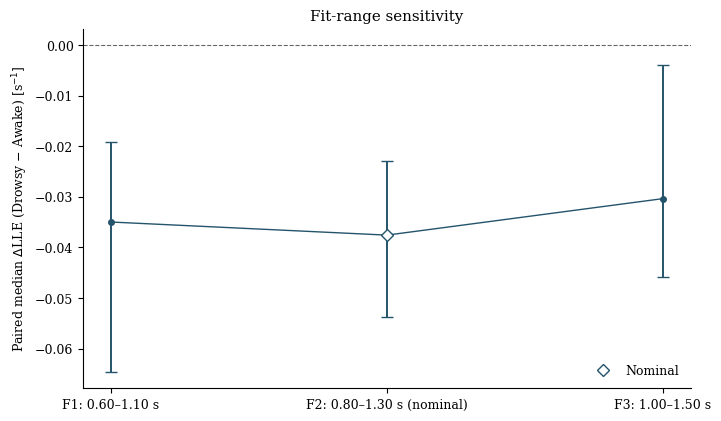

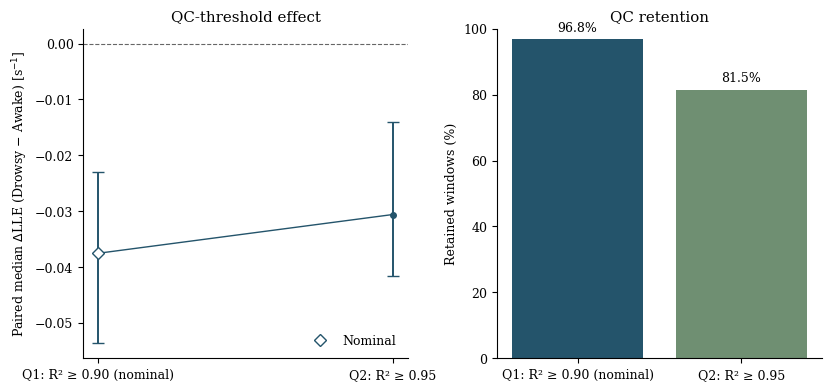

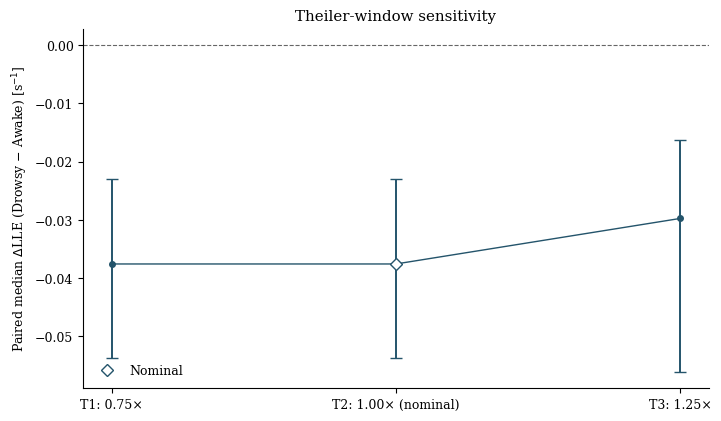

In [6]:
# Publication-ready inline figures
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})


def effect_panel(axis, summary, order, nominal_index, title):
    summary = summary.set_index("setting").reindex(order)
    x = np.arange(len(order))
    axis.vlines(x, summary["ci_low"], summary["ci_high"], color="#24546b", lw=1.4)
    axis.plot(x, summary["median_delta"], "o-", color="#24546b", lw=1.0, ms=4)
    axis.plot(x, summary["ci_low"], "_", color="#24546b", ms=8)
    axis.plot(x, summary["ci_high"], "_", color="#24546b", ms=8)
    axis.plot(
        nominal_index, summary.iloc[nominal_index]["median_delta"],
        marker="D", mfc="white", mec="#24546b", ms=6, ls="none",
        label="Nominal",
    )
    axis.axhline(0, color="0.4", ls="--", lw=.8)
    axis.set_xticks(x, order)
    axis.set_ylabel(r"Paired median $\Delta$LLE (Drowsy $-$ Awake) [s$^{-1}$]")
    axis.set_title(title)
    axis.legend(frameon=False)


fig, ax = plt.subplots(figsize=(7.1, 4.1), layout="constrained")
effect_panel(ax, fit_inference, fit_order, 1, "Fit-range sensitivity")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8), layout="constrained")
effect_panel(axes[0], qc_inference, qc_order, 0, "QC-threshold effect")
qc_plot = qc_inference.set_index("setting").reindex(qc_order)
x = np.arange(len(qc_order))
axes[1].bar(x, 100 * qc_plot["valid_fraction"], color=["#24546b", "#6f8f72"])
axes[1].set_xticks(x, qc_order)
axes[1].set_ylabel("Retained windows (%)")
axes[1].set_ylim(0, 100)
axes[1].set_title("QC retention")
for position, value in zip(x, 100 * qc_plot["valid_fraction"]):
    axes[1].text(position, value + 1.5, f"{value:.1f}%", ha="center", va="bottom")
plt.show()

fig, ax = plt.subplots(figsize=(7.1, 4.1), layout="constrained")
effect_panel(ax, theiler_inference, theiler_order, 1, "Theiler-window sensitivity")
plt.show()

In [7]:
# Deterministic reproducibility audit on representative 25/50 Hz windows
task_frame = pd.DataFrame({
    "task_index": np.arange(len(tasks)),
    "session": [task["session"] for task in tasks],
    "window_id": [task["window_id"] for task in tasks],
    "fs": [task["fs"] for task in tasks],
})
task_frame["fs_group_hz"] = np.where(task_frame["fs"] < 37.5, 25, 50)
representative_indices = []
for _, group in task_frame.groupby("fs_group_hz"):
    positions = sorted(set([0, len(group) // 2, len(group) - 1]))
    representative_indices.extend(group.iloc[positions]["task_index"].tolist())
audit_tasks = [tasks[int(index)] for index in representative_indices]
nominal_lookup = nominal.set_index(["session", "window_id"])


def finite_max_abs(first, second):
    first = np.asarray(first)
    second = np.asarray(second)
    if not np.array_equal(np.isnan(first), np.isnan(second)):
        return np.inf
    finite = np.isfinite(first) & np.isfinite(second)
    return float(np.max(np.abs(first[finite] - second[finite]))) if finite.any() else 0.0


audit_rows = []
for task in audit_tasks:
    kwargs = dict(
        sampling_rate=task["fs"], m=M, tau_samples=task["tau_samples"],
        fit_start_s=FIT_START_S, fit_end_s=FIT_END_S,
        max_follow_s=MAX_FOLLOW_S, theiler_s=task["theiler_base_s"],
        min_initial_pairs=MIN_INITIAL_PAIRS,
        min_fit_pairs=MIN_FIT_PAIRS, min_r2=MIN_R2,
    )
    with threadpool_limits(limits=1):
        first = compute_rosenstein_lle(task["signal"], **kwargs)
        second = compute_rosenstein_lle(task["signal"], **kwargs)
        states = reconstruct_phase_space(task["signal"], M, task["tau_samples"])
        neighbors_first, _ = find_nearest_neighbors(states, first.theiler_samples)
        neighbors_second, _ = find_nearest_neighbors(states, second.theiler_samples)
    fit_first = np.flatnonzero(
        (first.time_s >= FIT_START_S) & (first.time_s <= FIT_END_S)
        & np.isfinite(first.mean_log_distance)
        & (first.n_pairs_by_lag >= MIN_FIT_PAIRS)
    )
    fit_second = np.flatnonzero(
        (second.time_s >= FIT_START_S) & (second.time_s <= FIT_END_S)
        & np.isfinite(second.mean_log_distance)
        & (second.n_pairs_by_lag >= MIN_FIT_PAIRS)
    )
    cached = nominal_lookup.loc[(task["session"], task["window_id"])]
    audit_rows.append({
        "session": task["session"],
        "window_id": task["window_id"],
        "fs": task["fs"],
        "tau_samples_match": task["tau_samples"] == int(cached["tau_samples"]),
        "theiler_samples_match": first.theiler_samples == second.theiler_samples == int(cached["theiler_samples"]),
        "neighbor_mismatches": int(np.count_nonzero(neighbors_first != neighbors_second)),
        "divergence_max_abs_difference": finite_max_abs(first.mean_log_distance, second.mean_log_distance),
        "pair_support_mismatches": int(np.count_nonzero(first.n_pairs_by_lag != second.n_pairs_by_lag)),
        "fit_indices_match": np.array_equal(fit_first, fit_second),
        "repeat_lle_abs_difference": abs(first.lle - second.lle),
        "repeat_r2_abs_difference": abs(first.fit_r2 - second.fit_r2),
        "cache_lle_abs_difference": abs(first.lle - float(cached["lle_1_per_s"])),
        "cache_r2_abs_difference": abs(first.fit_r2 - float(cached["fit_r2"])),
    })

reproducibility_audit = pd.DataFrame(audit_rows)
mismatch_columns = [
    "neighbor_mismatches", "pair_support_mismatches",
]
audit_summary = pd.DataFrame({
    "audited_windows": [len(reproducibility_audit)],
    "sampling_rate_groups": [", ".join(map(str, sorted(task_frame["fs_group_hz"].unique())))],
    "max_abs_difference_lle_repeat": [reproducibility_audit["repeat_lle_abs_difference"].max()],
    "max_abs_difference_r2_repeat": [reproducibility_audit["repeat_r2_abs_difference"].max()],
    "max_abs_difference_lle_vs_cache": [reproducibility_audit["cache_lle_abs_difference"].max()],
    "max_abs_difference_r2_vs_cache": [reproducibility_audit["cache_r2_abs_difference"].max()],
    "total_neighbor_mismatches": [reproducibility_audit["neighbor_mismatches"].sum()],
    "total_pair_support_mismatches": [reproducibility_audit["pair_support_mismatches"].sum()],
    "fit_index_mismatches": [(~reproducibility_audit["fit_indices_match"]).sum()],
})
audit_pass = bool(
    reproducibility_audit["tau_samples_match"].all()
    and reproducibility_audit["theiler_samples_match"].all()
    and reproducibility_audit["fit_indices_match"].all()
    and reproducibility_audit[mismatch_columns].to_numpy().sum() == 0
    and audit_summary.filter(like="max_abs_difference").to_numpy().max() <= 1e-12
)
if not audit_pass:
    raise RuntimeError("Nominal reproducibility audit failed; investigate before interpretation.")

display(Markdown("## Reproducibility audit"))
display(reproducibility_audit.round(12))
display(audit_summary.round(12))

pair_support_audit = nominal.agg({
    "n_pairs_initial": ["min", lambda x: x.quantile(.25), "median"],
    "n_pairs_fit_min": ["min", lambda x: x.quantile(.25), "median"],
})
pair_support_audit.index = ["minimum", "Q1", "median"]
proximity = pd.DataFrame({
    "criterion": ["Initial pairs ≤ 100 (2× threshold)", "Fit pairs ≤ 60 (2× threshold)"],
    "windows": [
        int(nominal["n_pairs_initial"].le(2 * MIN_INITIAL_PAIRS).sum()),
        int(nominal["n_pairs_fit_min"].le(2 * MIN_FIT_PAIRS).sum()),
    ],
})
proximity["fraction"] = proximity["windows"] / len(nominal)
display(Markdown("### Pair-support audit for fixed thresholds"))
display(pair_support_audit.round(1))
display(proximity)

## Reproducibility audit

,session,window_id,fs,tau_samples_match,theiler_samples_match,neighbor_mismatches,divergence_max_abs_difference,pair_support_mismatches,fit_indices_match,repeat_lle_abs_difference,repeat_r2_abs_difference,cache_lle_abs_difference,cache_r2_abs_difference
0,4,1,24.991878,True,True,0,0.0,0,True,0.0,0.0,0.0,0.0
1,13,8,25.000378,True,True,0,0.0,0,True,0.0,0.0,0.0,0.0
2,25,42,24.995938,True,True,0,0.0,0,True,0.0,0.0,0.0,0.0
3,1,1,50.000000,True,True,0,0.0,0,True,0.0,0.0,0.0,0.0
4,1,16,50.000000,True,True,0,0.0,0,True,0.0,0.0,0.0,0.0
5,1,34,50.000000,True,True,0,0.0,0,True,0.0,0.0,0.0,0.0


,audited_windows,sampling_rate_groups,max_abs_difference_lle_repeat,max_abs_difference_r2_repeat,max_abs_difference_lle_vs_cache,max_abs_difference_r2_vs_cache,total_neighbor_mismatches,total_pair_support_mismatches,fit_index_mismatches
0,6,"25, 50",0.0,0.0,0.0,0.0,0,0,0


### Pair-support audit for fixed thresholds

,n_pairs_initial,n_pairs_fit_min
minimum,1471.0,1366.0
Q1,1472.0,1403.0
median,1472.0,1414.0


,criterion,windows,fraction
0,Initial pairs ≤ 100 (2× threshold),0,0.0
1,Fit pairs ≤ 60 (2× threshold),0,0.0


In [8]:
# Final summary and decision rules
def classify_experiment(summary, nominal_setting):
    ordered = summary.copy()
    nominal_effect = float(
        ordered.loc[ordered["setting"].eq(nominal_setting), "median_delta"].iloc[0]
    )
    effects = ordered["median_delta"].to_numpy(float)
    direction_preserved = bool(
        np.all(np.isfinite(effects))
        and nominal_effect != 0
        and np.all(np.sign(effects) == np.sign(nominal_effect))
    )
    if not direction_preserved:
        return "PARAMETER-SENSITIVE"
    relative_change = float(np.max(np.abs(effects - nominal_effect)) / abs(nominal_effect))
    paired_stable = int(ordered["paired_sessions"].min()) >= 18
    retention_span = float(ordered["valid_fraction"].max() - ordered["valid_fraction"].min())
    if relative_change <= 0.35 and paired_stable and retention_span <= 0.10:
        return "ROBUST"
    return "MODERATELY SENSITIVE"


experiment_summaries = [
    ("Fit interval", fit_inference, "F2: 0.80–1.30 s (nominal)"),
    ("QC threshold", qc_inference, "Q1: R² ≥ 0.90 (nominal)"),
    ("Theiler window", theiler_inference, "T2: 1.00× (nominal)"),
]
classifications = {
    name: classify_experiment(summary, nominal_setting)
    for name, summary, nominal_setting in experiment_summaries
}

final_parts = []
for sensitivity, summary, _ in experiment_summaries:
    part = summary.copy()
    part.insert(0, "Sensitivity", sensitivity)
    part["Valid windows"] = (
        part["valid_windows"].astype(str) + "/" + part["total_windows"].astype(str)
    )
    part["95% CI"] = part.apply(
        lambda row: f"[{row.ci_low:.6f}, {row.ci_high:.6f}]", axis=1
    )
    part["Direction"] = part.apply(
        lambda row: (
            f"{row.n_negative}/{row.paired_sessions} negative; "
            f"{row.n_positive} positive; {row.n_zero} zero"
        ), axis=1
    )
    part["Interpretation"] = classifications[sensitivity]
    final_parts.append(part.rename(columns={
        "setting": "Setting",
        "paired_sessions": "Paired sessions",
        "median_delta": "Median ΔLLE",
        "r_rb": "r_rb",
        "p": "p",
    })[[
        "Sensitivity", "Setting", "Valid windows", "Paired sessions",
        "Median ΔLLE", "95% CI", "r_rb", "Direction", "p", "Interpretation",
    ]])

final_summary = pd.concat(final_parts, ignore_index=True)
display(Markdown("## Final robustness summary"))
display(final_summary.round({"Median ΔLLE": 6, "r_rb": 4, "p": 6}))

reproducibility_status = "ROBUST" if audit_pass else "NEEDS FOLLOW-UP"
decision_table = pd.DataFrame({
    "Component": ["Fit interval", "QC threshold", "Theiler window", "Reproducibility"],
    "Conclusion": [
        classifications["Fit interval"],
        classifications["QC threshold"],
        classifications["Theiler window"],
        reproducibility_status,
    ],
})
display(decision_table)

verification_complete = bool(
    audit_pass
    and all(value != "PARAMETER-SENSITIVE" for value in classifications.values())
)
final_status = "COMPLETE" if verification_complete else "NEEDS FOLLOW-UP"
display(Markdown(
    "The nominal parameters remain unchanged. Robustness is judged from direction, "
    "effect magnitude, uncertainty, rank-biserial effect, direction count, retained "
    "windows, and paired-session coverage—not from the smallest p-value.\n\n"
    f"> **LLE verification status: {final_status}**"
))

## Final robustness summary

,Sensitivity,Setting,Valid windows,Paired sessions,Median ΔLLE,95% CI,r_rb,Direction,p,Interpretation
0,Fit interval,F1: 0.60–1.10 s,802/901,20,-0.034980,"[-0.064607, -0.019121]",-0.8571,18/20 negative; 2 positive; 0 zero,0.000261,ROBUST
1,Fit interval,F2: 0.80–1.30 s (nominal),872/901,20,-0.037570,"[-0.053698, -0.022976]",-0.8095,16/20 negative; 4 positive; 0 zero,0.000708,ROBUST
2,Fit interval,F3: 1.00–1.50 s,889/901,20,-0.030357,"[-0.045778, -0.003941]",-0.6571,15/20 negative; 5 positive; 0 zero,0.008308,ROBUST
3,QC threshold,Q1: R² ≥ 0.90 (nominal),872/901,20,-0.037570,"[-0.053698, -0.022976]",-0.8095,16/20 negative; 4 positive; 0 zero,0.000708,MODERATELY SENSITIVE
4,QC threshold,Q2: R² ≥ 0.95,734/901,20,-0.030618,"[-0.041701, -0.013987]",-0.7429,16/20 negative; 4 positive; 0 zero,0.002325,MODERATELY SENSITIVE
5,Theiler window,T1: 0.75×,872/901,20,-0.037570,"[-0.053698, -0.022976]",-0.8095,16/20 negative; 4 positive; 0 zero,0.000708,ROBUST
6,Theiler window,T2: 1.00× (nominal),872/901,20,-0.037570,"[-0.053698, -0.022976]",-0.8095,16/20 negative; 4 positive; 0 zero,0.000708,ROBUST
7,Theiler window,T3: 1.25×,874/901,20,-0.029763,"[-0.056095, -0.016331]",-0.7429,16/20 negative; 4 positive; 0 zero,0.002325,ROBUST


,Component,Conclusion
0,Fit interval,ROBUST
1,QC threshold,MODERATELY SENSITIVE
2,Theiler window,ROBUST
3,Reproducibility,ROBUST


The nominal parameters remain unchanged. Robustness is judged from direction, effect magnitude, uncertainty, rank-biserial effect, direction count, retained windows, and paired-session coverage—not from the smallest p-value.

> **LLE verification status: COMPLETE**

# Final LLE Robustness Verification Summary

## Scope and frozen configuration

Verification used the **901 primary processed PPG windows of 60 s from 20 sessions**. The nominal Rosenstein configuration remained fixed at $m=8$, $\tau=0.16$ s, Euclidean nearest admissible neighbour, a per-window spectral-mean-period Theiler window, fit interval 0.80–1.30 s, maximum follow time 5 s, minimum 50 initial pairs, minimum 30 fitted-region pairs, and nominal QC $R^2\geq0.90$. No parameter was reselected from the Awake–Drowsy result.

## Main results

| Sensitivity | Setting | Valid windows | Median $\Delta$LLE | Bootstrap 95% CI | $r_{rb}$ | Direction count | $p$ | Assessment |
|---|---|---:|---:|---:|---:|---:|---:|---|
| Fit interval | 0.60–1.10 s | 802/901 (89.0%) | −0.034980 | [−0.064607, −0.019121] | −0.8571 | 18/20 negative | 0.000261 | ROBUST |
| Fit interval | **0.80–1.30 s nominal** | 872/901 (96.8%) | **−0.037570** | **[−0.053698, −0.022976]** | **−0.8095** | **16/20 negative** | **0.000708** | ROBUST |
| Fit interval | 1.00–1.50 s | 889/901 (98.7%) | −0.030357 | [−0.045778, −0.003941] | −0.6571 | 15/20 negative | 0.008308 | ROBUST |
| QC threshold | $R^2\geq0.90$ nominal | 872/901 (96.8%) | −0.037570 | [−0.053698, −0.022976] | −0.8095 | 16/20 negative | 0.000708 | MODERATELY SENSITIVE |
| QC threshold | $R^2\geq0.95$ | 734/901 (81.5%) | −0.030618 | [−0.041701, −0.013987] | −0.7429 | 16/20 negative | 0.002325 | MODERATELY SENSITIVE |
| Theiler window | 0.75× spectral period | 872/901 (96.8%) | −0.037570 | [−0.053698, −0.022976] | −0.8095 | 16/20 negative | 0.000708 | ROBUST |
| Theiler window | **1.00× nominal** | 872/901 (96.8%) | **−0.037570** | **[−0.053698, −0.022976]** | **−0.8095** | **16/20 negative** | **0.000708** | ROBUST |
| Theiler window | 1.25× spectral period | 874/901 (97.0%) | −0.029763 | [−0.056095, −0.016331] | −0.7429 | 16/20 negative | 0.002325 | ROBUST |

All settings retained **20 paired sessions**. The fit-range experiment preserved a negative Awake–Drowsy contrast with all confidence intervals below zero. Tightening QC to $R^2\geq0.95$ reduced retention by 15.3 percentage points but preserved the effect direction, paired-session coverage, confidence-interval conclusion, and rank-biserial effect; QC is therefore moderately sensitive in retention rather than conclusion. Local Theiler perturbations also preserved direction and coverage.

Pair support was far above the fixed thresholds: the minimum initial support was 1,471 pairs versus the threshold of 50, and the minimum fitted-region support was 1,366 pairs versus the threshold of 30. No primary window lay within two times either threshold.

## Reproducibility

A deterministic audit on six representative windows spanning the 25 and 50 Hz sampling-rate groups reproduced $\tau$ samples, Theiler samples, selected neighbours, divergence curves, pair-support trajectories, fit indices, LLE, and $R^2$ exactly. The maximum absolute difference for repeated LLE/$R^2$ and comparison with the nominal cache was **0**, with **0 mismatches**.

The evidence supports a stable negative paired $\Delta$LLE across reasonable fit intervals, QC thresholds, and local Theiler perturbations. The frozen nominal configuration is retained unchanged.

> **LLE verification status: COMPLETE**

# Với LLE, em kiểm tra ba yếu tố nhạy nhất của Rosenstein là khoảng fit, ngưỡng chất lượng hồi quy và Theiler window. Khi thay đổi hợp lý cả ba yếu tố, hiệu ứng Drowsy–Awake của LLE vẫn giữ âm, toàn bộ 20 session vẫn được ghép cặp và các khoảng tin cậy đều nằm dưới 0. Khi siết ngưỡng R² từ 0,90 lên 0,95, số window giữ lại giảm nhưng kết luận không đổi. Ngoài ra, audit tái lập cho kết quả LLE, R², đường divergence và neighbour selection khớp hoàn toàn. Vì vậy em coi LLE đã đủ bằng chứng về cả độ bền và tính tái lập để freeze.